In [31]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
#%matplotlib notebook
#%autosave 0
    
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.INFO, datefmt='%I:%M:%S')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [32]:
import json
from typing import Dict, Optional, Tuple, List, Union
import random

class Distribution:
    def __init__(self, name: str, **params):
        """
        Unified distribution object to encapsulate name and parameters.

        :param name: Name of the distribution (e.g., 'normal', 'uniform').
        :param params: Parameters specific to the distribution.
        """
        self.name = name
        self.params = params

    def to_dict(self) -> Dict:
        """Convert the distribution to a dictionary."""
        return {
            "name": self.name,
            "params": self.params
        }

    @classmethod
    def from_dict(cls, data: Dict):
        """Create a Distribution instance from a dictionary."""
        return cls(name=data["name"], **data.get("params", {}))

    def generate_value(self, range: Union[Tuple[float, float], List[Union[int, str]]]) -> Union[float, int, str]:
        """
        Generate a value based on the distribution within the specified range.

        :param range: Tuple specifying the minimum and maximum values or a list of discrete options.
        :return: Generated value.
        """
        if isinstance(range, list):
            return random.choice(range)

        min_val, max_val = range

        if self.name == "normal":
            mean = self.params.get("mean", (min_val + max_val) / 2)
            std_dev = self.params.get("std_dev", (max_val - min_val) / 6)
            return max(min(random.gauss(mean, std_dev), max_val), min_val)

        elif self.name == "truncated_gauss":
            mean = self.params.get("mean", (min_val + max_val) / 2)
            std_dev = self.params.get("std_dev", (max_val - min_val) / 6)
            value = random.gauss(mean, std_dev)
            while not (min_val <= value <= max_val):
                value = random.gauss(mean, std_dev)
            return value

        elif self.name == "weibull":
            scale = self.params.get("scale", (max_val - min_val) / 2)
            shape = self.params.get("shape", 1.5)
            return max(min(min_val + random.weibullvariate(scale, shape), max_val), min_val)

        elif self.name == "uniform":
            return random.uniform(min_val, max_val)

        elif self.name == "exponential":
            rate = self.params.get("rate", 1.0)
            return max(min_val, min(random.expovariate(rate), max_val))

        elif self.name == "lognormal":
            mean = self.params.get("mean", (min_val + max_val) / 2)
            sigma = self.params.get("sigma", (max_val - min_val) / 6)
            return max(min_val, min(random.lognormvariate(mean, sigma), max_val))

        elif self.name == "beta":
            alpha = self.params.get("alpha", 2.0)
            beta = self.params.get("beta", 5.0)
            return min_val + (random.betavariate(alpha, beta) * (max_val - min_val))

        elif self.name == "gamma":
            shape = self.params.get("shape", 2.0)
            scale = self.params.get("scale", 1.0)
            return max(min_val, min(random.gammavariate(shape, scale), max_val))

        elif self.name == "cauchy":
            location = self.params.get("location", (min_val + max_val) / 2)
            scale = self.params.get("scale", (max_val - min_val) / 4)
            value = random.uniform(location - scale, location + scale)
            return max(min_val, min(value, max_val))

        else:
            raise ValueError(f"Unsupported distribution: {self.name}")

class Parameter:
    def __init__(self, name: str, value: Union[float, int, str], 
                 range: Optional[Union[Tuple[float, float], List[Union[int, str]]]] = None, 
                 distribution: Optional[Distribution] = None, 
                 type: Optional[str] = None):
        """
        Unified class for a parameter.

        :param name: Name of the parameter
        :param value: Value of the parameter
        :param range: Range of the parameter (optional)
        :param distribution: Distribution object for the parameter (optional)
        :param type: Type of the parameter ("Constant" or "Variable")
        """
        self.name = name
        self.value = value
        self.range = range
        self.type = type or ("Constant" if range is None else "Variable")
        self.distribution = distribution or (Distribution("uniform") if self.type == "Variable" else None)

    def set_type(self, new_type: str):
        """
        Change the type of the parameter to "Constant" or "Variable".

        :param new_type: The new type to set ("Constant" or "Variable").
        """
        if new_type not in ["Constant", "Variable"]:
            raise ValueError("Type must be 'Constant' or 'Variable'")

        self.type = new_type

        if self.type == "Constant":
            self.range = None
            self.distribution = None
        elif self.type == "Variable" and not self.distribution:
            self.distribution = Distribution("uniform")

    def to_dict(self) -> Dict:
        """Convert the parameter to a dictionary."""
        return {
            "name": self.name,
            "value": self.value,
            "range": self.range,
            "type": self.type,
            "distribution": self.distribution.to_dict() if self.distribution else None
        }

    @classmethod
    def from_dict(cls, data: Dict):
        """Create a Parameter instance from a dictionary."""
        distribution = None
        if data.get("distribution"):
            distribution = Distribution.from_dict(data["distribution"])
        return cls(
            name=data["name"],
            value=data["value"],
            range=data.get("range"),
            distribution=distribution,
            type=data.get("type")
        )

    def to_json(self) -> str:
        """Serialize the parameter to a JSON string."""
        return json.dumps(self.to_dict(), indent=4)

    @classmethod
    def from_json(cls, json_str: str):
        """Create a Parameter instance from a JSON string."""
        data = json.loads(json_str)
        return cls.from_dict(data)

    def sample_value(self) -> Union[float, int, str]:
        """
        Sample and update the value based on the defined distribution.
        """
        if self.type == "Constant":
            return self.value
        self.value = self.distribution.generate_value(self.range)
        return self.value

    def sample_values(self, n: int) -> List[Union[float, int, str]]:
        """
        Generate n sampled values based on the defined distribution.
        """
        if self.type == "Constant":
            return [self.value] * n
        return [self.distribution.generate_value(self.range) for _ in range(n)]


    @property
    def min(self):
        return self.range[0]

    @property
    def max(self):
        return self.range[1]

    def __repr__(self):
        
        try:
            value_range = f"{self.min:.2g},{self.max:.2g}"
        except:
            if len(self.range) > 4:
                value_range = self.range[:4] + ["..."]
            else:
                value_range = self.range[:4]
        return f"({self.name}|{self.value}|[{value_range}]|{self.type})"
    
p = Parameter(name="p", value=5.0, range=(0.01, 10.00))
p    
 

(p|5.0|[0.01,10]|Variable)

In [33]:
param_discrete = Parameter(
    name="discrete_param",
    value="a",
    range=["a", "b", "c", "d", "e", "f"]
)
param_discrete

(discrete_param|a|[['a', 'b', 'c', 'd', '...']]|Variable)

In [34]:

param_discrete

(discrete_param|a|[['a', 'b', 'c', 'd', '...']]|Variable)

In [35]:
   
# Beispiel: Parameter erstellen und als JSON speichern
param_constant = Parameter(name="constant_param", value=10.0)
print(param_constant.to_json())

param_variable = Parameter(name="variable_param", value=5.0, range=(0.0, 10.0))
print(param_variable.to_json())

param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=5.0, std_dev=1.0)
)
print(param_distributed.to_json())

param_discrete = Parameter(
    name="discrete_param",
    value="a",
    range=["a", "b", "c"]
)
print(param_discrete.to_json())

# Sampling von mehreren Werten
sampled_values = param_distributed.sample_values(10)
print(f"Sampled values: {sampled_values}")

sampled_discrete_values = param_discrete.sample_values(10)
print(f"Sampled discrete values: {sampled_discrete_values}")

# Typänderung
param_distributed.set_type("Constant")
print(param_distributed.to_json())

# Sampling nach Typänderung
sampled_values_constant = param_distributed.sample_values(10)
print(f"Sampled values after type change: {sampled_values_constant}")

# JSON-Import
loaded_param = Parameter.from_json(param_distributed.to_json())
print(loaded_param.to_dict())

{
    "name": "constant_param",
    "value": 10.0,
    "range": null,
    "type": "Constant",
    "distribution": null
}
{
    "name": "variable_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "type": "Variable",
    "distribution": {
        "name": "uniform",
        "params": {}
    }
}
{
    "name": "distributed_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "type": "Variable",
    "distribution": {
        "name": "truncated_gauss",
        "params": {
            "mean": 5.0,
            "std_dev": 1.0
        }
    }
}
{
    "name": "discrete_param",
    "value": "a",
    "range": [
        "a",
        "b",
        "c"
    ],
    "type": "Variable",
    "distribution": {
        "name": "uniform",
        "params": {}
    }
}
Sampled values: [4.885952354742727, 6.055996373255509, 5.388964522314538, 4.094716989820279, 3.9526886916864683, 3.1405205215016236, 5.659584643027048, 5.812026863627966, 3.842903026714163, 4.887

In [36]:
c = Parameter(name="c", value=5.0, range=(0.01, 10.00))
c.type = "Constant"
c

(c|5.0|[0.01,10]|Constant)

In [37]:
    
# Beispiel: Parameter erstellen und als JSON speichern
param_constant = Parameter(name="constant_param", value=10.0)
print(param_constant.to_json())

param_variable = Parameter(name="variable_param", value=5.0, range=(0.0, 10.0))
print(param_variable.to_json())

param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=5.0, std_dev=1.0)
)
print(param_distributed.to_json())

# Sampling von mehreren Werten
sampled_values = param_distributed.sample_values(10)
print(f"Sampled values: {sampled_values}")

# Typänderung
param_distributed.set_type("Constant")
print(param_distributed.to_json())

# Sampling nach Typänderung
sampled_values_constant = param_distributed.sample_values(10)
print(f"Sampled values after type change: {sampled_values_constant}")

# JSON-Import
loaded_param = Parameter.from_json(param_distributed.to_json())
print(loaded_param.to_dict())

{
    "name": "constant_param",
    "value": 10.0,
    "range": null,
    "type": "Constant",
    "distribution": null
}
{
    "name": "variable_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "type": "Variable",
    "distribution": {
        "name": "uniform",
        "params": {}
    }
}
{
    "name": "distributed_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "type": "Variable",
    "distribution": {
        "name": "truncated_gauss",
        "params": {
            "mean": 5.0,
            "std_dev": 1.0
        }
    }
}
Sampled values: [3.5458570368163276, 5.16187264375604, 5.469195856550312, 5.8892208488965325, 5.608578652604324, 5.21036459357762, 6.271793320158304, 4.2509682251340655, 5.953216393559369, 3.789704716970302]
{
    "name": "distributed_param",
    "value": 5.0,
    "range": null,
    "type": "Constant",
    "distribution": null
}
Sampled values after type change: [5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5

In [38]:
param_constant.sample_values(10)

[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]

In [39]:
param_variable.sample_values(10)

[3.481773426421716,
 8.367316961502322,
 6.034611148645582,
 6.09683303694761,
 5.0476688475593425,
 2.853952509337593,
 4.655539365816509,
 4.834060052586436,
 7.527715230237797,
 8.646414930777574]

In [40]:
param_distributed.sample_values(10)

[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]

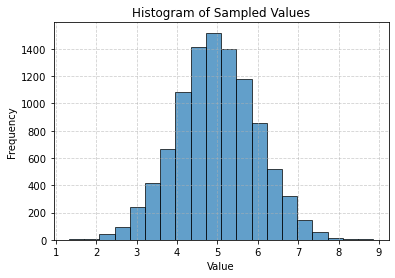

In [41]:
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=5.0, std_dev=1.0)
)
sampled_values = param_distributed.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)


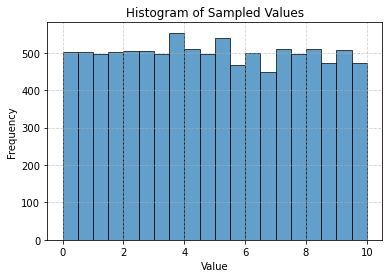

In [42]:
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution=Distribution("uniform")
)
sampled_values = param_distributed.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)


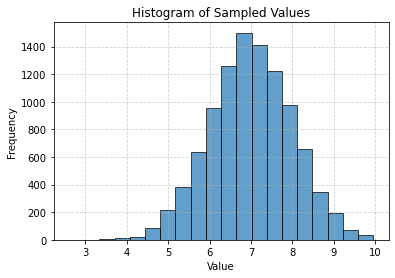

In [43]:

# Plot als Histogramm
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=7.0, std_dev=1.0)
)
#param_distributed.type = "Constant"
sampled_values = param_distributed.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

(2.0, 10.0)


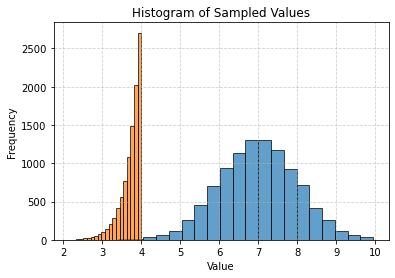

In [53]:

# Plot als Histogramm
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(2.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=7.0, std_dev=1.0)
)
#param_distributed.type = "Constant"
sampled_values = param_distributed.sample_values(10000)
print(param_distributed.range)
param_distributed.range = (2,4)
sampled_values2 = param_distributed.sample_values(10000)

plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.hist(sampled_values2, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

In [54]:
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(2.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=7.0, std_dev=1.0)
)
j = param_distributed.to_json()
j

'{\n    "name": "distributed_param",\n    "value": 5.0,\n    "range": [\n        2.0,\n        10.0\n    ],\n    "type": "Variable",\n    "distribution": {\n        "name": "truncated_gauss",\n        "params": {\n            "mean": 7.0,\n            "std_dev": 1.0\n        }\n    }\n}'

In [55]:
p = Parameter.from_json(j)
p

(distributed_param|5.0|[2,10]|Variable)

(2.0, 10.0)


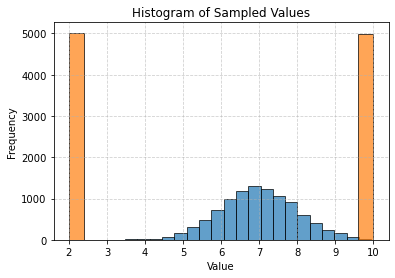

In [56]:
sampled_values = param_distributed.sample_values(10000)
sampled_values2 = p.sample_values(10000)
print(param_distributed.range)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.hist(sampled_values2, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

In [57]:
p = Parameter(
    name="a",
    value=5.0,
    range=(2.0, 10.0),
    #distribution=Distribution("truncated_gauss", mean=7.0, std_dev=1.0)
)
p

(a|5.0|[2,10]|Variable)

(2.0, 10.0)


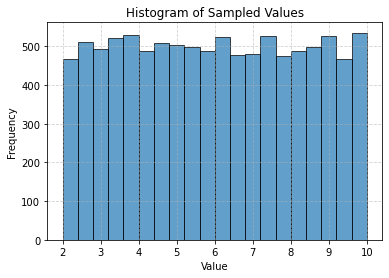

In [50]:
sampled_values = p.sample_values(10000)
print(param_distributed.range)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)